# **Read CKPT**

In [ ]:
import torch
import json

# 读取 .pt 文件
pt_path = "/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt/141503-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-11/optimizer.pt"
pt_path1 = "/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt/Test_staging_6-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-100/optimizer.pt"
meta = torch.load(pt_path, map_location='cpu', weights_only=True)
meta1 = torch.load(pt_path1, map_location='cpu', weights_only=True)
print("=== optimizer1 ===")
print(meta)
print("=== optimizer_ori ===")
print(meta1)

# # 读取 .json 文件
# json_path = "/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt/Test_staging_4-SST2-Qwen3-1.7B-mezo-ft-1e-6-1e-4-0/checkpoint-200/zo_replay_history.json"
# with open(json_path, 'r') as f:
#     history = json.load(f)
# print("\n=== zo_replay_history.json ===")
# print(history)

=== optimizer1 ===
{'state': {}, 'param_groups': [{'lr': 1e-07, 'weight_decay': 0.0, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'initial_lr': 1e-07, 'params': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 18

In [ ]:
import os
from safetensors.torch import load_file

path = "/home/ubuntu/.cache/huggingface/hub/models--Qwen--Qwen3-1.7B/snapshots/70d244cc86ccca08cf5af4e1e306ecf908b1ad5e/model-00001-of-00002.safetensors"
assert os.path.exists(path), f"File not found: {path}"

state = load_file(path)  # dict: name -> torch.Tensor

print("Loaded:", path)
print("Num tensors:", len(state))

# Show a quick summary (first ~40 tensors)
for i, (k, v) in enumerate(state.items()):
    print(f"{i:03d}  {k:60s}  shape={tuple(v.shape)}  dtype={v.dtype}  device={v.device}")

In [ ]:
import torch
from safetensors.torch import load_file

state = load_file(path)
path1 = "/home/ubuntu/.cache/huggingface/hub/models--Qwen--Qwen3-1.7B/snapshots/70d244cc86ccca08cf5af4e1e306ecf908b1ad5e/model-00002-of-00002.safetensors"
state1 = load_file(path1)

w_lm = state1["lm_head.weight"]
w_emb = state["model.embed_tokens.weight"]

print("lm_head.weight:", tuple(w_lm.shape), w_lm.dtype, w_lm.device)
print("model.embed_tokens.weight:", tuple(w_emb.shape), w_emb.dtype, w_emb.device)

same_shape = (w_lm.shape == w_emb.shape)
same_dtype = (w_lm.dtype == w_emb.dtype)

# exact equality + closeness
exact_equal = torch.equal(w_lm, w_emb)
max_abs_diff = (w_lm - w_emb).abs().max().item() if same_shape else None
allclose = torch.allclose(w_lm, w_emb, rtol=0.0, atol=0.0) if same_shape else False

print("\nSame shape:", same_shape)
print("Same dtype:", same_dtype)
print("torch.equal:", exact_equal)
print("max|diff|:", max_abs_diff)
print("allclose(atol=0, rtol=0):", allclose)

# If you want a more tolerant check too:
if same_shape:
    print("allclose(atol=1e-6, rtol=1e-6):", torch.allclose(w_lm, w_emb, atol=1e-6, rtol=1e-6))

# **Evaluate**

In [12]:
# train
!python3 /home/users/u0001609/NonStopZO2/experiments/analyze_checkpoint_time.py \
    /home/users/u0001609/MEZO_logs/1.log \
    /home/users/u0001609/MEZO_logs/2.log \
    /home/users/u0001609/MEZO_logs/r1.log \
    /home/users/u0001609/MEZO_logs/r2.log 

Log file: /home/users/u0001609/MEZO_logs/1.log
Train runtime (e2e): 334.8082s
Total checkpoints:  10
Average time:       20.9967s
Median time:        20.5350s
Standard deviation: 2.0156s
Total time spent:   209.9670s

Resume Information:
  [Full Resume] Total time from program start to first step: 111.259s

Log file: /home/users/u0001609/MEZO_logs/2.log
Train runtime (e2e): 172.6074s
Total checkpoints:  1000
Average time:       0.0116s
Median time:        0.0110s
Standard deviation: 0.0039s
Total time spent:   11.5800s

Resume Information:
  [Full Resume] Total time from program start to first step: 136.769s

Log file: /home/users/u0001609/MEZO_logs/r1.log
Train runtime (e2e): 308.1385s
Total checkpoints:  9
Average time:       20.0820s
Median time:        19.6750s
Standard deviation: 2.0571s
Total time spent:   180.7380s

Resume Information:
  [Full Resume] Total checkpoint resume time: 37.843s
  [Full Resume] Total time from program start to first step: 141.085s

No checkpoint, resum

# **Plot**

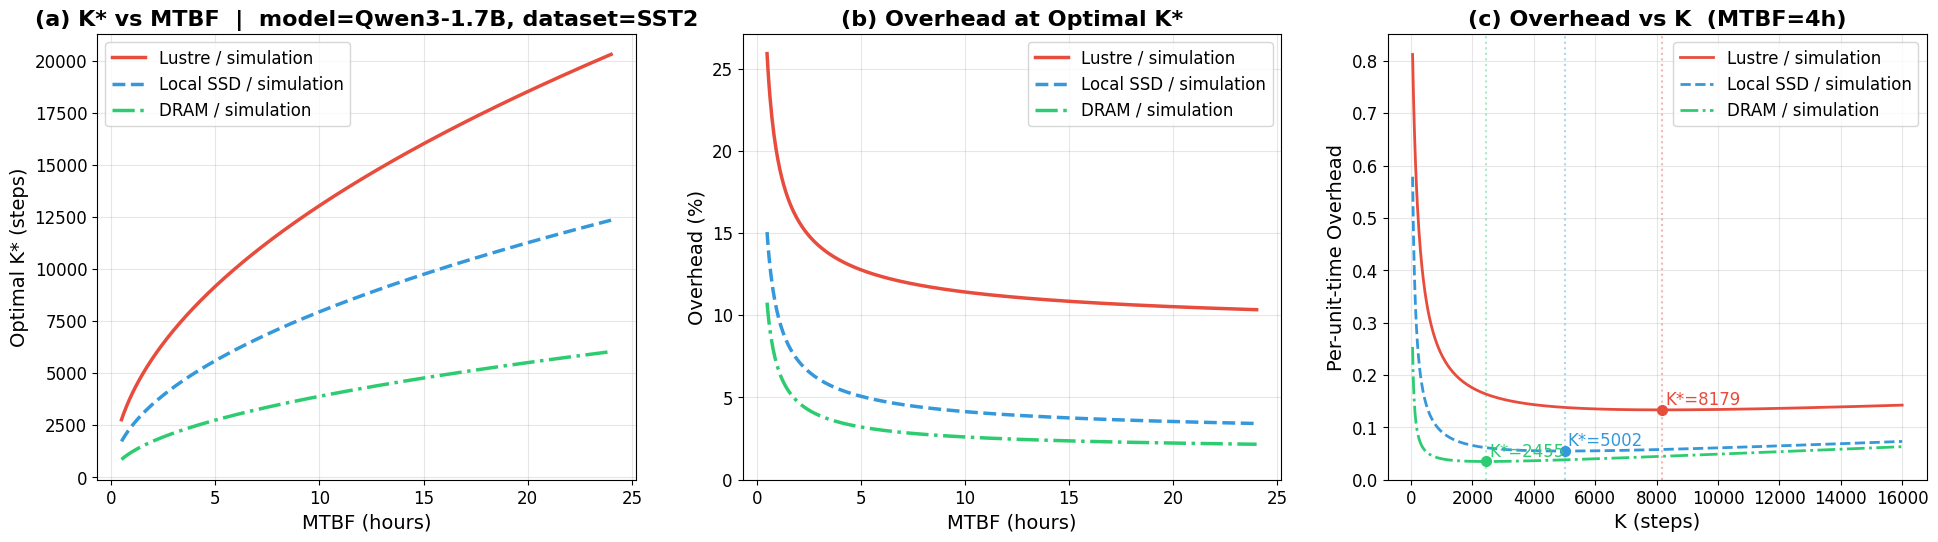

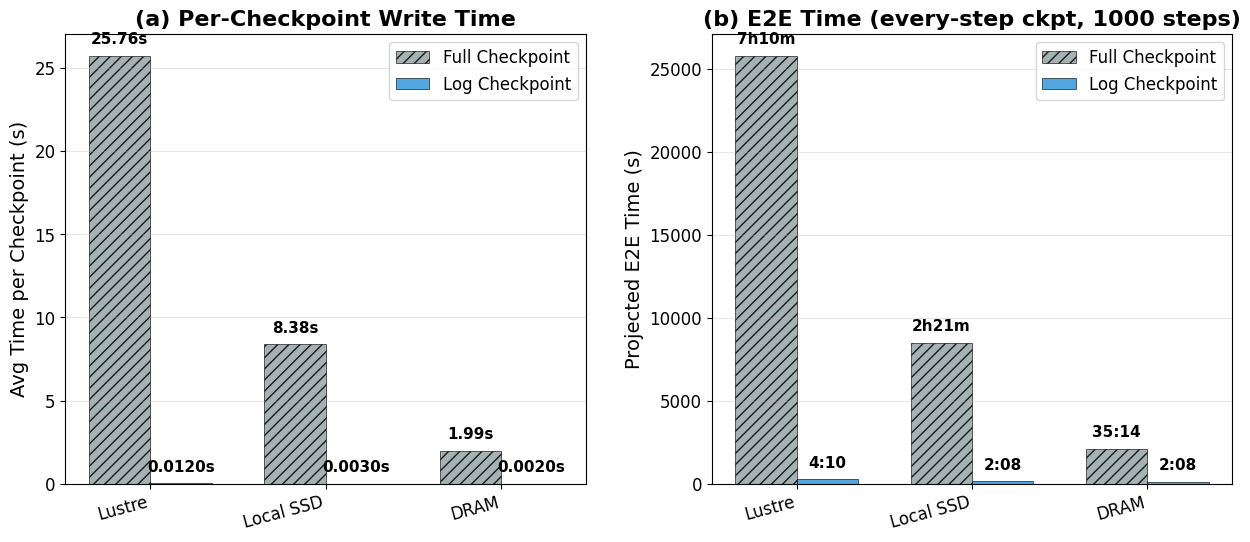

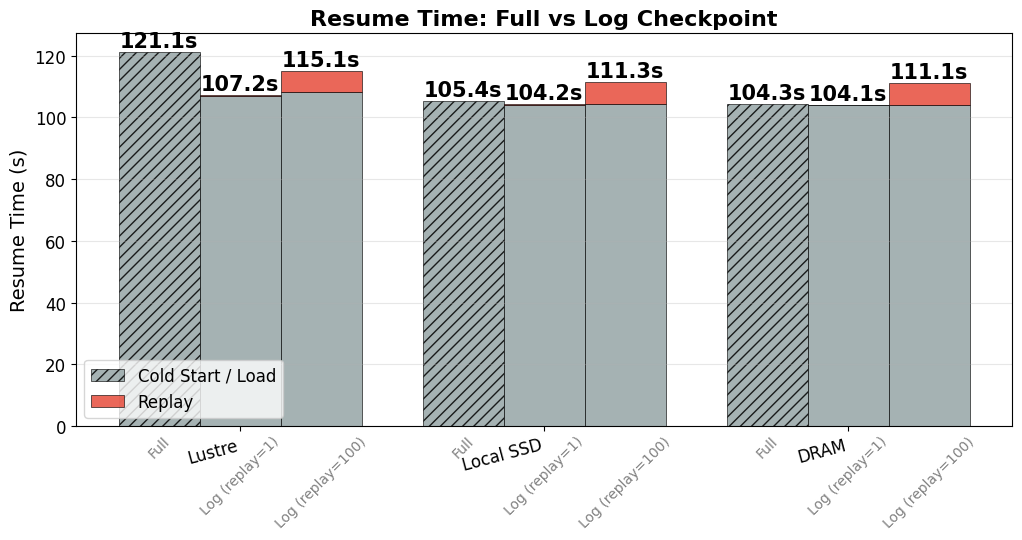

In [9]:
"""
ZO Checkpoint 成本模型 — 数据 + 画图配置
==========================================
只需要填测量数据和配置参数，其他全部自动计算。
数据按 "Model / Dataset" → FS 分组。
"""

import sys
import importlib
sys.path.insert(0, '/home/users/u0001609/NonStopZO2/experiments')

import zo_optimal_K_model
importlib.reload(zo_optimal_K_model)
from zo_optimal_K_model import (
    plot_cost_model,
    plot_e2e_comparison,
    plot_resume_comparison,
)
import matplotlib.pyplot as plt

# ╔══════════════════════════════════════════════════════════════╗
# ║                    在这里填测量数据                            ║
# ╚══════════════════════════════════════════════════════════════╝

EXPERIMENTS = {
    # ==================== Qwen3-1.7B / SST2 ====================
    "Qwen3-1.7B / SST2": {
        "ts": 0.128,        # 每步训练时间 (秒)
        "total_steps": 1000,
        "Info": [
            {
                "FS": "Lustre",
                "avg_full_ckpt_time": 25.758,
                "avg_log_ckpt_time": 0.012,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 326.720,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 250.525,},
                ],
                "full checkpoint resume time": 121.130,
                "log checkpoint resume time": {"type": "simulation", "data": [
                    {"replay_steps": 1, "replay_time": 0.390, "total_resume_time": 107.171},
                    {"replay_steps": 100, "replay_time": 7.244, "total_resume_time": 115.130}]
                    }
            },
            {
                "FS": "Local SSD",
                "avg_full_ckpt_time": 8.380,
                "avg_log_ckpt_time": 0.003,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 208.666,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 128.980,},
                ],
                "full checkpoint resume time": 105.402,
                "log checkpoint resume time": {"type": "simulation", "data": [
                    {"replay_steps": 1, "replay_time": 0.392, "total_resume_time": 104.242},
                    {"replay_steps": 100, "replay_time": 7.335, "total_resume_time": 111.338}]
                    }
            },
            {
                "FS": "DRAM",
                "avg_full_ckpt_time": 1.990,
                "avg_log_ckpt_time": 0.002,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 144.372,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 128.533,},
                ],
                "full checkpoint resume time": 104.345,
                "log checkpoint resume time": {"type": "simulation", "data": [
                    {"replay_steps": 1, "replay_time": 0.395, "total_resume_time": 104.126},
                    {"replay_steps": 100, "replay_time": 7.437, "total_resume_time": 111.135}]
                    }
            },
        ],
    },
    # ==================== Qwen3-1.7B / SQuAD ====================
    "Qwen3-1.7B / SQuAD": {
        "ts": 0.242,        # 每步训练时间 (秒)
        "total_steps": 1000,
        "Info": [
            {
                "FS": "Lustre",
                "avg_full_ckpt_time": 20.894,
                "avg_log_ckpt_time": 0.071,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 499.3334,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 366.092,},
                ],
                # TODO: 补充 "full checkpoint resume time"
                "log checkpoint resume time": [
                    {"type": "simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.386, "total_resume_time": 8.299},
                        {"replay_steps": 100, "replay_time": 7.325, "total_resume_time": 15.080}]
                    },
                    {"type": "no-simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.828, "total_resume_time": 8.786},
                        {"replay_steps": 100, "replay_time": 2.602, "total_resume_time": 10.456}]
                    },
                ]
            },
        ],
    },

    # ==================== Qwen3-8B / SST2 ====================
    "Qwen3-8B / SST2": {
        "ts": 0.443,        # 每步训练时间 (秒)
        "total_steps": 1000,
        "Info": [
            {
                "FS": "Lustre",
                "avg_full_ckpt_time": 134.751,
                "avg_log_ckpt_time": 0.020,
                "e2e_train": [
                {"checkpoint_type": "full", "checkpoint numbers": 10, "e2e_time_seconds": 1790.513,},
                {"checkpoint_type": "log", "checkpoint numbers": 1000, "e2e_time_seconds": 2465.772,},
                ],
                # TODO: 补充 "full checkpoint resume time"
                "log checkpoint resume time": [
                    {"type": "simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.598, "total_resume_time": 16.323},
                        {"replay_steps": 100, "replay_time": 27.449, "total_resume_time": 42.279}]
                    },
                    {"type": "no-simulation", "data": [
                        {"replay_steps": 1, "replay_time": 0.416, "total_resume_time": 15.380},
                        {"replay_steps": 100, "replay_time": 8.893, "total_resume_time": 24.457}]
                    },
                ]
            },
        ],
    },
}

# ========== MTBF 配置 ==========
MTBF_CONFIG = {
    "range_hours": (0.5, 24),
    "demo_hours": 4,
    "table_values": [1, 2, 4, 8, 12, 24],
}

# ╔══════════════════════════════════════════════════════════════╗
# ║                    Plot 配置                                  ║
# ╚══════════════════════════════════════════════════════════════╝

# --- Plot 1: Cost Model (3 subplots: K* vs MTBF, Overhead%, Overhead vs K) ---
# 可选维度: model, dataset, FS, simulation
# 设为具体值 → 固定该维度 (只画匹配的数据); 设为 None → 该维度每个值各画一条线
# 例: model="Qwen3-1.7B", dataset="SST2", FS=None, simulation=None
#     → 画 Qwen3-1.7B/SST2 的所有 FS × simulation 组合
PLOT1_CONFIG = {
    "model": "Qwen3-1.7B",      # "Qwen3-1.7B" / "Qwen3-8B" / None
    "dataset": "SST2",           # "SST2" / "SQuAD" / None
    "FS": None,                  # "Lustre" / "Local SSD" / "DRAM" / None
    "simulation": None,          # "simulation" / "no-simulation" / None
}

# --- Plot 2: E2E Comparison (Full vs Log, 归一化为每步 ckpt 1 次) ---
# group_by: x 轴分组维度，3 选 1: "model" / "dataset" / "FS"
# 其他两个维度用于过滤 (设为具体值过滤, None = 不过滤)
# 归一化公式: pure_train = e2e - avg_ckpt × num_ckpts;
#            projected = pure_train + avg_ckpt × total_steps
PLOT2_CONFIG = {
    "group_by": "FS",            # x 轴分组: "model" / "dataset" / "FS"
    "model": "Qwen3-1.7B",      # 过滤 (当 group_by != "model" 时生效)
    "dataset": "SST2",           # 过滤 (当 group_by != "dataset" 时生效)
}

# --- Plot 3: Resume Time (Full vs Log, stacked bar) ---
# group_by: x 轴分组维度，3 选 1: "model" / "dataset" / "FS"
# simulation: 过滤 log resume 类型 ("simulation" / "no-simulation" / None=全部)
# Log bar 分两段: 底部=cold_start/load, 顶部=replay (U*replay_steps)
# total_resume_time 直接用提供的数据; U 由所有数据点 polyfit 拟合
PLOT3_CONFIG = {
    "group_by": "FS",            # x 轴分组: "model" / "dataset" / "FS"
    "model": "Qwen3-1.7B",      # 过滤
    "dataset": "SST2",           # 过滤
    "simulation": "simulation",  # "simulation" / "no-simulation" / None
}

# ╔══════════════════════════════════════════════════════════════╗
# ║                       画图                                    ║
# ╚══════════════════════════════════════════════════════════════╝

plot_cost_model(EXPERIMENTS, PLOT1_CONFIG, MTBF_CONFIG)
plot_e2e_comparison(EXPERIMENTS, PLOT2_CONFIG)
plot_resume_comparison(EXPERIMENTS, PLOT3_CONFIG)

plt.show()

In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      2
    Core(s) per socket:      96
    Socket(s):               1
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      70%
    CPU max MHz:             3716.8860
    CPU min MHz:             1500.0000
    BogoMIPS:                5099.99
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         